In [73]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks')
from multiclass_functions1 import * # my module import
import torch
from torch import nn, optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cpu


In [74]:
BATCH_SIZE = 32
LR = 1e-2
EPOCH = 100
criterion = nn.MSELoss()
new_model_train = True
save_model_path = f"/content/drive/MyDrive/Colab Notebooks/results/UAT.pt"

In [75]:
def Test(model,X_test,Y_test):
    model.eval()
    with torch.no_grad():
        X_test = X_test.to(DEVICE)
        Y_test = Y_test.to(DEVICE)
        # inference
        y_hat = model(X_test)
        # loss
        loss = F.mse_loss(y_hat, Y_test)

    plt.plot(X_test,Y_test,'b:',label="true_curve")
    plt.plot(X_test,y_hat,'r',label="test")
    plt.xlabel("x",fontsize=20)
    plt.ylabel("y",fontsize=20)
    plt.grid()
    plt.legend(fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    print(f"Test loss: {loss.item()}")

class Custom_Dataset(torch.utils.data.Dataset):
    def __init__(self, X, Y, transform=None):
        self.X = X
        self.Y = Y
        self.transform = transform

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.transform:
            x = self.transform(x)
        y = self.Y[idx]
        return x, y

In [76]:
# model 선언
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        # case 1: hidden layer 하나여도 괜찮게 된다! (심지어 노드 3개)
        self.fcs = nn.Sequential(nn.Linear(1, 3),
                                 nn.ReLU(),
                                 nn.Linear(3, 1))

        # case 2: 물론 노드를 늘리면 더 잘한다
        self.fcs = nn.Sequential(nn.Linear(1, 10),
                                 nn.ReLU(),
                                 nn.Linear(10, 1))

        # case 3: 늘릴수록 좀더 부드러워짐
        self.fcs = nn.Sequential(nn.Linear(1, 100),
                                 nn.ReLU(),
                                 nn.Linear(100, 1))

        # case 4: 천개로 늘리면..? 잘되지만 안보여준 data에 대해선 잘 못함 (overfitting)
        self.fcs = nn.Sequential(nn.Linear(1, 1000),
                                 nn.ReLU(),
                                 nn.Linear(1000, 1))

        # case 5: 깊이를 늘려도 노드 수가 너무 적으면 안된다
        self.fcs = nn.Sequential(nn.Linear(1, 3),
                                 nn.ReLU(),
                                 nn.Linear(3, 3),
                                 nn.ReLU(),
                                 nn.Linear(3, 3),
                                 nn.ReLU(),
                                 nn.Linear(3, 3),
                                 nn.ReLU(),
                                 nn.Linear(3, 3),
                                 nn.ReLU(),
                                 nn.Linear(3, 1))

        # case 6-1: 노드 수를 적당히 키우고 깊이를 늘림 (부드럽다!)
        self.fcs = nn.Sequential(nn.Linear(1, 10),
                                 nn.ReLU(),
                                 nn.Linear(10, 10),
                                 nn.ReLU(),
                                 nn.Linear(10, 10),
                                 nn.ReLU(),
                                 nn.Linear(10, 10),
                                 nn.ReLU(),
                                 nn.Linear(10, 10),
                                 nn.ReLU(),
                                 nn.Linear(10, 1))

        # case 6-2: 비교를 위해.. 얕으면 어땠었지?
        # => 노드가 많으면 좀더 사이사이가 좁아져서 디테일을 잘 표현
        #    깊이가 깊으면 nonlinearity가 좀더 커진다고 해석 가능
        self.fcs = nn.Sequential(nn.Linear(1, 10),
                                 nn.ReLU(),
                                 nn.Linear(10, 1))

    def forward(self,x):
        x = torch.flatten(x, start_dim=1)
        x = self.fcs(x)
        return x

In [77]:
# training 과 test 함수 선언, -10부터 10까지 training에 사용 -15부터 15까지 test에 사용 -> 예상되는 결과로는 트레이닝에 사용한 -10부터 10까지 데이터는 테스트 결과가 좋을것임.
X=torch.linspace(-10,10,1000).reshape(-1,1)   # -10부터 10까지 1000개를 쪼개서 x
Y=X**2                                        # x를 제곱하는 트레이닝 함수를 만듬
X_test=torch.linspace(-15,15,1000).reshape(-1,1)    # -15부터 15까지 1000개를 쪼개서 x
Y_test=X_test**2                                    # x를 제곱하는 테스트 함수를 만듬

In [78]:
train_DS = Custom_Dataset(X, Y)
train_DL = torch.utils.data.DataLoader(train_DS, batch_size = BATCH_SIZE, shuffle = True)

In [79]:
model=MLP().to(DEVICE)
print(model)
x_batch, _ = next(iter(train_DL))
print(model(x_batch.to(DEVICE)).shape)

MLP(
  (fcs): Sequential(
    (0): Linear(in_features=1, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=1, bias=True)
  )
)
torch.Size([32, 1])


Epoch: 1 train loss: 1845.903
--------------------
Epoch: 2 train loss: 1227.095
--------------------
Epoch: 3 train loss: 529.353
--------------------
Epoch: 4 train loss: 206.417
--------------------
Epoch: 5 train loss: 157.15
--------------------
Epoch: 6 train loss: 146.793
--------------------
Epoch: 7 train loss: 136.787
--------------------
Epoch: 8 train loss: 128.178
--------------------
Epoch: 9 train loss: 118.803
--------------------
Epoch: 10 train loss: 110.773
--------------------
Epoch: 11 train loss: 103.336
--------------------
Epoch: 12 train loss: 95.729
--------------------
Epoch: 13 train loss: 88.876
--------------------
Epoch: 14 train loss: 82.21
--------------------
Epoch: 15 train loss: 75.965
--------------------
Epoch: 16 train loss: 70.416
--------------------
Epoch: 17 train loss: 64.55
--------------------
Epoch: 18 train loss: 59.641
--------------------
Epoch: 19 train loss: 54.789
--------------------
Epoch: 20 train loss: 50.655
--------------------

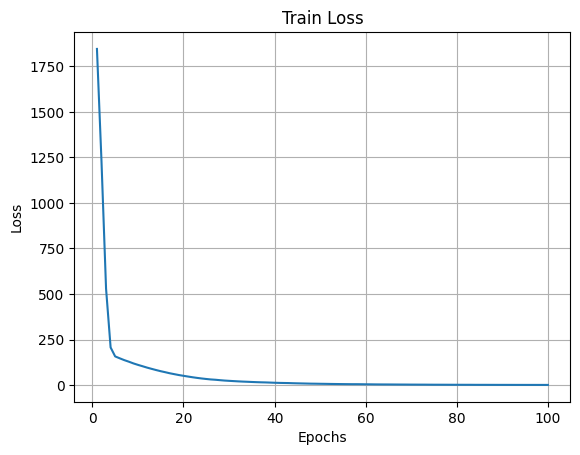

In [80]:
if new_model_train:
    optimizer = optim.Adam(model.parameters(), lr = LR)
    loss_history = Train(model, train_DL, criterion, optimizer, LR=LR, EPOCH=EPOCH)

    torch.save(model, save_model_path)

    plt.figure()
    plt.plot(range(1,EPOCH+1),loss_history)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Train Loss")
    plt.grid()

In [81]:
load_model = torch.load(save_model_path, map_location=DEVICE, weights_only=False)

Test loss: 214.88458251953125
31


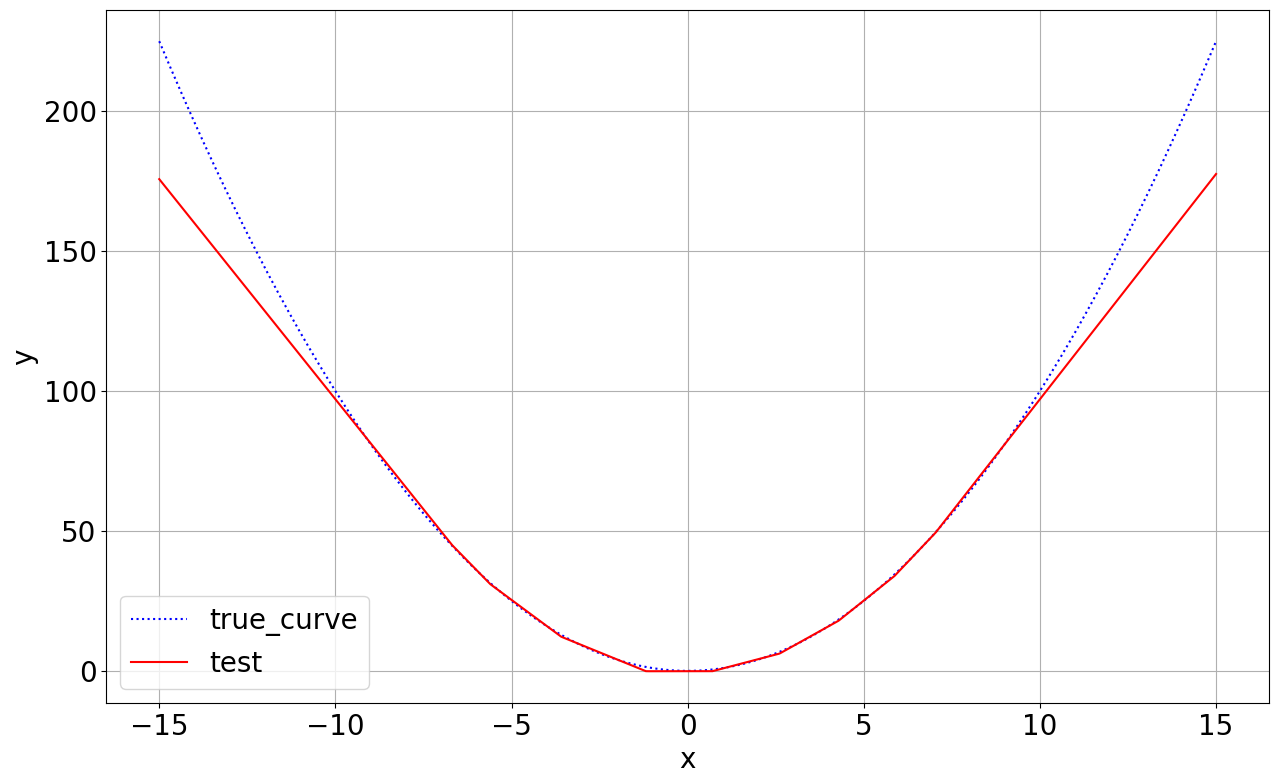

In [82]:
plt.figure(figsize=[15,9])
Test(load_model, X_test, Y_test)
print(count_params(load_model))

In [83]:
# 보여드린 증명 방식대로 훈련되는 것은 아니라는 것 확인!
print(model.fcs[0].weight)
print(model.fcs[0].bias)
print(model.fcs[2].weight)
print(model.fcs[2].bias)

Parameter containing:
tensor([[-1.9434],
        [ 0.9198],
        [-0.0133],
        [-1.1801],
        [ 1.3589],
        [ 1.1568],
        [ 1.8008],
        [-2.3295],
        [ 2.5095],
        [-1.1290]], requires_grad=True)
Parameter containing:
tensor([-6.9725, -6.4615, -0.2717, -7.8852, -5.8275, -6.7866, -4.7015, -2.7542,
        -1.7550, -6.3349], requires_grad=True)
Parameter containing:
tensor([[ 2.1646,  3.1102, -0.0153,  2.3879,  2.2498,  2.7377,  2.0604,  2.1988,
          1.3159,  3.1715]], requires_grad=True)
Parameter containing:
tensor([-0.1259], requires_grad=True)
